<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
ROC-AUC - Threshold
</b></font> </br></p>

---


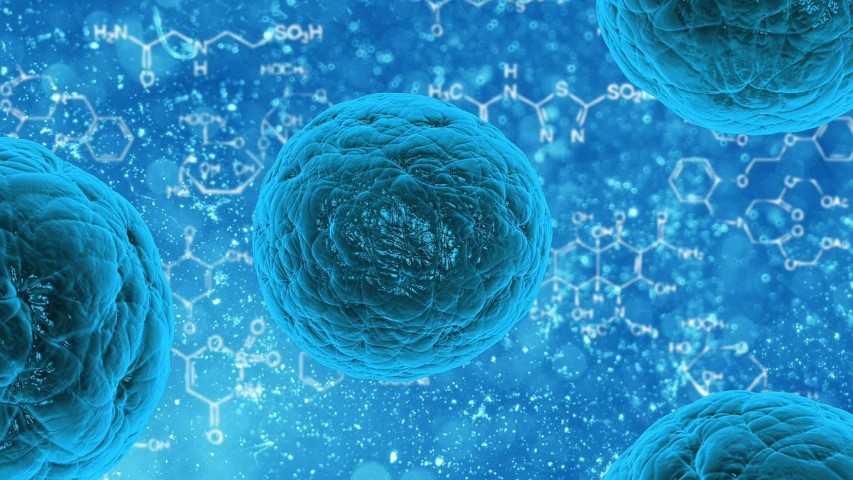

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# **0  <font color='orange'>|</font> Install & Import**
***

In [11]:
# Install
!uv pip install --system -q ucimlrepo

In [12]:
# Import
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

import plotly.express as px
import plotly.subplots as sp
import matplotlib.pyplot as plt

In [13]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

# 1 | Understand
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 1
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

In [14]:
# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
data = breast_cancer_wisconsin_original.data.features
target = breast_cancer_wisconsin_original.data.targets

# **2 <font color='orange'>|</font> Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features codieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Missing Values
</font></p>

In [15]:
data = data.dropna()

In [16]:
target = target.loc[data.index] # Löschen der korrespondierenden Targets analog data.dropna()

<p><font color='black' size="5">
Umcodierung
</font></p>

In [17]:
target.replace([2, 4], [0, 1], inplace=True) # bösartig → 1

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [18]:
from sklearn.model_selection import train_test_split
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.20, random_state=42, stratify=target)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

((546, 9), (137, 9), (546, 1), (137, 1))

# **3 <font color='orange'>|</font> Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Valdiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [19]:
model = MLPClassifier(verbose=0, random_state=42)
model.fit(data_train, target_train)

MLPClassifier(random_state=42, verbose=0)

<p><font color='black' size="5">
Loss-Entwicklung
</font></p>

In [20]:
title_ = 'Loss-Entwicklung'
px.line(y=model.loss_curve_, title=title_, labels={'x':'Epochen', 'y':'Loss-Wert'}, width=800, height=400)

# **4 <font color='orange'>|</font> Evaluate**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
# Prognose 0/1
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

In [29]:
# Prognose Wahrscheinlichkeiten für 0/1
target_train_proba = model.predict_proba(data_train)
target_test_proba = model.predict_proba(data_test)

array([[9.94832079e-01, 5.16792060e-03],
       [9.88633111e-01, 1.13668893e-02],
       [9.63217575e-01, 3.67824251e-02],
       [9.85676173e-01, 1.43238274e-02],
       [9.92526620e-01, 7.47338005e-03],
       [3.60420248e-03, 9.96395798e-01],
       [9.93676792e-01, 6.32320818e-03],
       [9.83009248e-01, 1.69907520e-02],
       [4.28273926e-03, 9.95717261e-01],
       [9.90764098e-01, 9.23590231e-03],
       [4.02134754e-04, 9.99597865e-01],
       [9.77744977e-01, 2.22550228e-02],
       [9.87528205e-01, 1.24717952e-02],
       [8.48996683e-04, 9.99151003e-01],
       [3.80551084e-04, 9.99619449e-01],
       [9.78696213e-01, 2.13037868e-02],
       [9.92526620e-01, 7.47338005e-03],
       [5.18980838e-02, 9.48101916e-01],
       [9.83449171e-01, 1.65508287e-02],
       [2.97765018e-05, 9.99970223e-01],
       [9.93993815e-01, 6.00618464e-03],
       [4.91082313e-02, 9.50891769e-01],
       [7.69986258e-03, 9.92300137e-01],
       [9.75373682e-01, 2.46263179e-02],
       [1.200216


<p><font color='black' size="5">
Accuracy
</font></p>

In [23]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print (f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

Modell: MLPClassifier(random_state=42, verbose=0) -- Train -- Accuracy: 98.53


In [24]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print (f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}")

Modell: MLPClassifier(random_state=42, verbose=0) -- Test -- Accuracy: 94.89



<p><font color='black' size="5">
Confusion Matrix
</font></p>

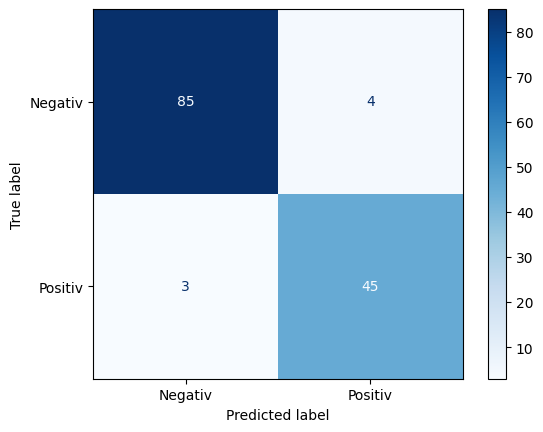

In [25]:
display_labels=['Negativ','Positiv']
conf_matrix = confusion_matrix(target_test, target_test_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels))

# **5 <font color='orange'>|</font> Deploy**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# **A <font color='orange'>|</font> ROC-AUC**
---

Die ROC-AUC Analyse ist ein Werkzeug, um beim maschinellen Lernen die Leistung eines Klassifikationsmodells zu bewerten.  

1. **ROC-Kurve (Receiver Operating Characteristic)**: Dies ist ein Graph, der zeigt, wie gut ein Modell zwischen zwei Klassen (zum Beispiel positiv und negativ) unterscheiden kann. Auf der x-Achse wird die Falsch-Positiv-Rate (FPR) abgebildet, und auf der y-Achse die Wahr-Positiv-Rate (TPR). Die FPR zeigt, wie oft das Modell fälschlicherweise eine negative Instanz als positiv klassifiziert, während die TPR zeigt, wie oft das Modell korrekt eine positive Instanz als positiv erkennt.

$$
\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$
<br>

$$
\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
$$
<br>

2. **AUC (Area Under the Curve)**: Dies ist ein Maß dafür, wie gut das Modell insgesamt ist. Es wird durch Berechnung der Fläche unter der ROC-Kurve ermittelt. Ein AUC-Wert von 1,0 bedeutet, dass das Modell perfekt klassifiziert, während ein Wert von 0,5 bedeutet, dass es nicht besser ist als zufälliges Raten.


Die ROC-Kurve wird durch Variation der Schwellwerte für die Entscheidungsgrenze des Modells zwischen 0 und 1 ermittelt.

- **Schwellwert (Threshold)**: Dies ist der Wert, bei dem das Modell entscheidet, ob eine Instanz als positiv oder negativ klassifiziert wird. Indem man den Schwellwert von 0 bis 1 variiert, verändert man, wann das Modell eine Instanz als positiv klassifiziert.

- **Variation der Schwellwerte**: Bei einem niedrigen Schwellwert klassifiziert das Modell mehr Instanzen als positiv, was zu einer höheren Wahr-Positiv-Rate (TPR) und möglicherweise auch zu einer höheren Falsch-Positiv-Rate (FPR) führt. Umgekehrt führt ein höherer Schwellwert dazu, dass das Modell weniger Instanzen als positiv klassifiziert, was die FPR senken kann, aber auch die TPR verringert.

- **Erstellung der ROC-Kurve**: Für jeden Schwellwert wird ein Punkt auf der ROC-Kurve gezeichnet, der aus der FPR und TPR besteht. Die Kurve zeigt, wie sich die TPR und FPR verändern, wenn der Schwellwert variiert wird.


<p><font color='black' size="5">
ROC-AUC Kurve (Yellowbrick)
</font></p>

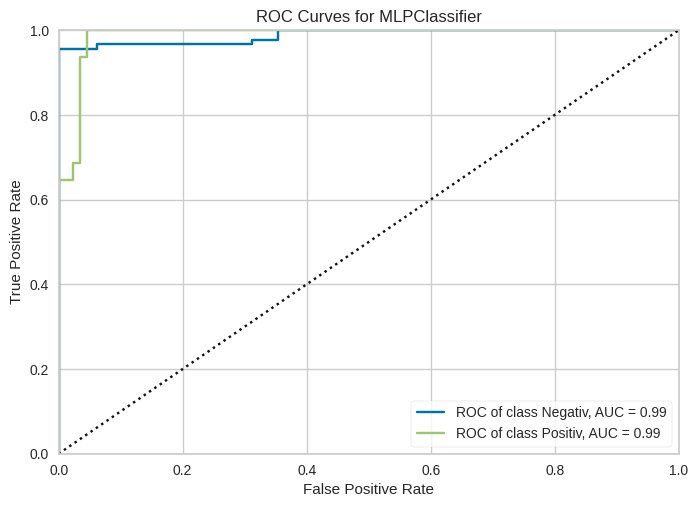

<Axes: title={'center': 'ROC Curves for MLPClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [28]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(model, micro=False, macro=False, classes=["Negativ", "Positiv"])

visualizer.fit(data_train, target_train)        # Fit the training data to the visualizer
visualizer.score(data_test, target_test)        # Evaluate the model on the test data
visualizer.show()

<p><font color='black' size="5">
ROC-AUC Kurve sklearn
</font></p>

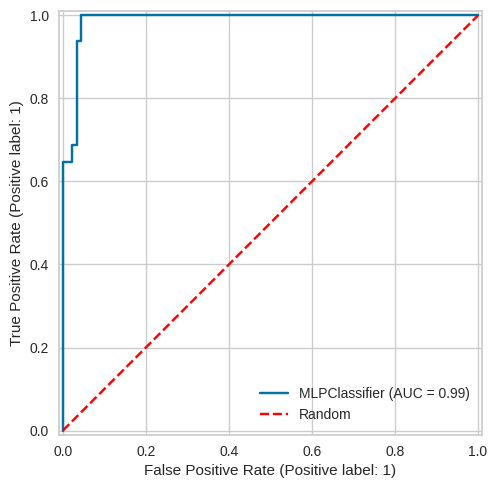

In [30]:
RocCurveDisplay.from_predictions(target_test, target_test_proba[:, 1], name="MLPClassifier")
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random')

plt.legend()
plt.show()

In [31]:
rocauc = roc_auc_score(target_train, model.predict_proba(data_train)[:, 1])
print(f'AUC Train: {rocauc:.2f}')

rocauc = roc_auc_score(target_test, model.predict_proba(data_test)[:, 1])
print(f'AUC Test: {rocauc:.2f}')

AUC Train: 1.00
AUC Test: 0.99


In [32]:
fpr, tpr, thresholds = roc_curve(target_test, target_test_proba[:, 1])

<p><font color='black' size="5">
Optimaler Schwellenwert
</font></p>

 Der Punkt auf der Kurve, der der linken oberen Ecke am nächsten liegt.

In [33]:
# Euklidischen Abstand zu jedem Punkt von der linken oberen Ecke berechnen
distances = np.sqrt((1 - tpr) ** 2 + fpr ** 2)

# Den Index des minimalen Abstands finden
optimal_idx = np.argmin(distances)

# Den optimalen Schwellenwert finden
optimal_threshold = thresholds[optimal_idx]

print(f"Optimaler Schwellenwert nach Euklidischen Abstand : {optimal_threshold:0.3f}")

Optimaler Schwellenwert nach Euklidischen Abstand : 0.323


In [34]:
# Manhattan Abstand zu jedem Punkt von der linken oberen Ecke berechnen
manhattan_distances = np.abs(1 - tpr) + np.abs(fpr)

# Den Index des minimalen Abstands finden
optimal_idx = np.argmin(manhattan_distances)

# Den optimalen Schwellenwert finden
optimal_threshold = thresholds[optimal_idx]

print(f"Optimaler Schwellenwert nach Manhatten Abstand: {optimal_threshold:0.3f}")

Optimaler Schwellenwert nach Manhatten Abstand: 0.323


In [35]:
# Youden's J-Index berechnen
j_index = tpr - fpr

# Den Index des maximalen J-Index finden
optimal_idx = np.argmax(j_index)

# Den optimalen Schwellenwert finden
optimal_threshold = thresholds[optimal_idx]

print(f"Optimaler Schwellenwert nach Youden's J-Index: {optimal_threshold:0.3f}")

Optimaler Schwellenwert nach Youden's J-Index: 0.323


<p><font color='black' size="5">
Anpassung Schwellwert auf Basis ROC/AUC
</font></p>

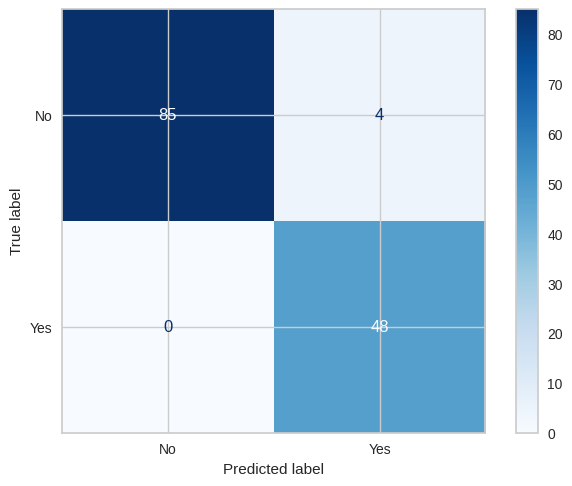

In [36]:
threshold = 0.323 # Distanz: Manhatten und Youden's J-Index
new_target_pred = (target_test_proba[:, 1]>= threshold).astype(int)
conf_matrix = confusion_matrix(target_test, new_target_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['No','Yes'])
disp.plot(cmap='Blues')

In [37]:
print(classification_report(target_test, new_target_pred, target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       1.00      0.96      0.98        89
         Yes       0.92      1.00      0.96        48

    accuracy                           0.97       137
   macro avg       0.96      0.98      0.97       137
weighted avg       0.97      0.97      0.97       137



# **B <font color='orange'>|</font> Fehler 1./2. Art**
---

**Fehler 1. Art (α)** - False Positive Rate
Wahrscheinlichkeit, fälschlicherweise die Nullhypothese abzulehnen bzw. fälschlicherweise eine positive Entscheidung zu treffen, wenn die tatsächliche Situation negativ ist:

<br>
$$
\text{FPR} = \frac{\text{FP}}{\text{TN} + \text{FP}}
$$


<br>

**Fehler 2. Art (β)** - False Negative Rate
Wahrscheinlichkeit, fälschlicherweise die Nullhypothese beizubehalten bzw. fälschlicherweise eine negative Entscheidung zu treffen, wenn die tatsächliche Situation positiv ist:

<br>
$$
\text{FNR} = \frac{\text{FN}}{\text{TP} + \text{FN}}
$$

<br>

**Nullhypothese (H₀)**   
Standardannahme oder Ausgangshypothese, die besagt, dass kein Effekt oder Unterschied existiert. Sie wird abgelehnt, wenn die Daten signifikante Evidenz für die Alternativhypothese liefern.

<p><font color='black' size="5">
Schwellwert auf Basis Analyse Fehler 1./2. Art - niedrige FNR (cancer)
</font></p>

In [38]:
# Fehler 1./2. Art
# Die FNR misst den Anteil der tatsächlich kranken Personen, die fälschlicherweise als gesund eingestuft werden.
# Im Anwednungsfall "Cancer" könnte es daher sinnvoll sein, dass möglichst wenige krankheitspositive Fälle übersehen
# werden.
#
target_proba = model.predict_proba(data_test)

best_threshold = 0
best_fnr = 1
best_fpr = 1

for threshold in range(0, 101):
    new_target_test_pred = (target_test_proba[:, 1] >= (threshold / 100)).astype(int)
    conf_matrix = confusion_matrix(target_test, new_target_test_pred)
    TN, FP, FN, TP = conf_matrix.ravel()
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0  # Vermeidung von Division durch 0
    FNR = FN / (FN + TP) if (FN + TP) != 0 else 0  # Vermeidung von Division durch 0
    # print(f"FNR: {FNR:0.7f} -- FPR: {FPR:0.7f} -- Threshold: {threshold/100:.2f}")

    # Optimalen Punkt finden: min. FNR (0, wenn möglich) und gleichzeitig min. FPR
    if FNR == 0 and FPR < best_fpr:
        best_threshold = threshold / 100
        best_fnr = FNR
        best_fpr = FPR

In [39]:
print(f"\nOptimaler Schwellwert: {best_threshold:.2f} (FNR: {best_fnr:0.5f}, FPR: {best_fpr:0.5f})")


Optimaler Schwellwert: 0.12 (FNR: 0.00000, FPR: 0.04494)


<p><font color='black' size="5">
Confusion Matrix auf Basis Analyse Fehler 1./2. Art
</font></p>

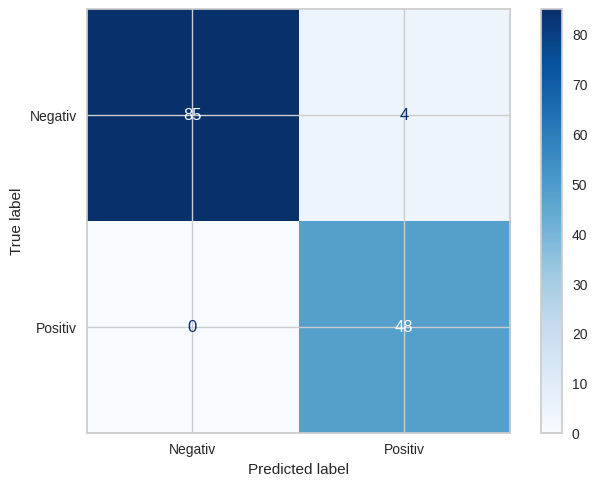

In [40]:
threshold = 0.12 #  Analyse Fehler 1./2. Art
new_target_test_pred = (target_test_proba[:,1]>= threshold).astype(int)
conf_matrix = confusion_matrix(target_test, new_target_test_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, new_target_test_pred, target_names=display_labels))